<a href="https://colab.research.google.com/github/SnazzyBeatle115/UG54/blob/main/chapters/Assignments/Assignment5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 5



# Write your name and  email

David Shen
ds6870@nyu.edu


# Exercises





**1. Data Cleaning**

You will work with the same dataset as in Assigment 1.
The dataset has address

`url='https://github.com/amoreira2/UG54/blob/main/assets/data/Assignment1.xlsx?raw=true'`

Do the followings:

- Import pandas, numpy, matplotlib, and load the data set.
- Import the datasets of industry returns and risk free rate.
- Parse the date.
- Set the index.
- Drop missing observations.
- Construct a dataframe with only excess returns.
- Call this dataframe with the 49 excess returns time series `df`.
- Call `df.head()` to check if everything works

**_Hint:_**
You did it in assignment 1 (the dataframe name was different), simply copy and paste your code.

In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas.tseries.offsets import MonthEnd

url='https://github.com/amoreira2/Fin418/blob/main/assets/data/Assignment1.xlsx?raw=true'

# Import the data
df_industries = pd.read_excel(
    url,
    sheet_name='49_Industry_Portfolios',
    skiprows=6,
    na_values=['-99.99', '-999'],
    usecols="A:AX"
)


# Rename the column with date information
df_industries.rename(columns={df_industries.columns[0]: 'date'}, inplace=True)

# Convert the date column to datetime
df_industries['date'] = pd.to_datetime(df_industries['date'], format='%Y%m')

# Set date as the index
df_industries.set_index('date', inplace=True)

# Check the dataframe
df_industries.info()

df = df_industries
df.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1069 entries, 1926-07-01 to 2015-07-01
Data columns (total 49 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Agric   1069 non-null   float64
 1   Food    1069 non-null   float64
 2   Soda    625 non-null    float64
 3   Beer    1069 non-null   float64
 4   Smoke   1069 non-null   float64
 5   Toys    1069 non-null   float64
 6   Fun     1069 non-null   float64
 7   Books   1069 non-null   float64
 8   Hshld   1069 non-null   float64
 9   Clths   1069 non-null   float64
 10  Hlth    553 non-null    float64
 11  MedEq   1069 non-null   float64
 12  Drugs   1069 non-null   float64
 13  Chems   1069 non-null   float64
 14  Rubbr   1009 non-null   float64
 15  Txtls   1069 non-null   float64
 16  BldMt   1069 non-null   float64
 17  Cnstr   1069 non-null   float64
 18  Steel   1069 non-null   float64
 19  FabPr   625 non-null    float64
 20  Mach    1069 non-null   float64
 21  ElcEq   1069 non-nu

,Agric,Food,Soda,Beer,Smoke,Toys,Fun,Books,Hshld,Clths,...,Boxes,Trans,Whlsl,Rtail,Meals,Banks,Insur,RlEst,Fin,Other
date,,,,,,,,,,,,,,,,,,,,,
1926-07-01,2.37,0.12,NaN,-5.19,1.29,8.65,2.50,50.21,-0.48,8.08,...,7.70,1.94,-23.79,0.07,1.87,4.61,-0.54,2.89,-4.85,5.20
1926-08-01,2.23,2.68,NaN,27.03,6.50,16.81,-0.76,42.98,-3.58,-2.51,...,-2.38,4.88,5.39,-0.75,-0.13,11.83,2.57,5.30,-0.57,6.76
1926-09-01,-0.57,1.58,NaN,4.02,1.26,8.33,6.42,-4.91,0.73,-0.51,...,-5.54,0.06,-7.87,0.25,-0.56,-1.75,0.72,-3.06,-3.14,-3.86
1926-10-01,-0.46,-3.68,NaN,-3.31,1.06,-1.40,-5.09,5.37,-4.68,0.12,...,-5.08,-2.64,-15.38,-2.20,-4.11,-11.82,-4.28,-5.74,2.07,-8.49
1926-11-01,6.75,6.26,NaN,7.29,4.55,0.00,1.82,-6.40,-0.54,1.87,...,3.84,1.60,4.67,6.52,4.33,-2.97,3.58,2.21,4.92,4.00


**2. Expected excess return estimation**

Compute the sample mean as the estimators for the expected excess returns of the 49 assets.

Call this `ERe`.

**_Hint:_**
Use risk-free rates from the "Market_proxy" sheet.

In [102]:
# your code below

df_rf = pd.read_excel(
    url,
    sheet_name='Market_proxy',
    skiprows=5,
    usecols="A:C"
)
df_rf.rename(columns={df_rf.columns[0]: 'date'}, inplace=True)
df_rf['date'] = pd.to_datetime(df_rf['date'], format='%Y%m')
df_rf.set_index('date', inplace=True)
df_rf.head()

ERe = (df.sub(df_rf['RF'], axis=0)).dropna()

ERe.head()

,Agric,Food,Soda,Beer,Smoke,Toys,Fun,Books,Hshld,Clths,...,Boxes,Trans,Whlsl,Rtail,Meals,Banks,Insur,RlEst,Fin,Other
date,,,,,,,,,,,,,,,,,,,,,
1969-07-01,-9.24,-7.49,-4.07,-2.60,-5.29,-8.33,-10.72,-11.59,-3.99,-12.58,...,-3.67,-13.02,-10.47,-8.81,-10.88,-6.80,-10.73,-13.79,-10.19,-12.55
1969-08-01,4.08,4.05,4.97,6.17,3.49,5.89,11.03,9.53,4.25,2.01,...,5.61,5.08,5.81,7.78,8.36,11.77,8.27,14.97,8.56,7.07
1969-09-01,0.52,-1.23,4.60,-1.55,3.52,1.25,0.02,-1.27,-1.16,-3.32,...,0.56,-2.23,-0.28,-1.37,-1.64,-3.73,6.39,-4.14,-2.91,-4.81
1969-10-01,15.62,7.39,6.21,11.03,11.82,5.81,12.44,6.90,5.79,6.71,...,2.87,4.16,10.60,5.63,8.37,10.14,5.10,3.19,9.55,0.11
1969-11-01,-2.82,-1.24,-5.44,-3.34,0.09,-8.80,-4.04,-4.41,-2.95,-3.61,...,-2.48,-8.45,-7.23,-4.64,-2.99,-8.58,-5.42,-6.96,-7.22,-4.08


**3. Expected excess return uncertainty**

We will now construct an estimator for the amount of uncertainty in our sample mean estimator. If we assume that each individual asset is uncorrelated over time (not terrible assumption), then the variance of the mean is

$$var(\bar{r_i}) = var(\frac{\sum_t^T r_{i,t}}{T})=\frac{\sum_t^T var( r_{i,t})}{T^2} = \frac{var(r_{i,t})}{T}$$

So all you need is the sample size (T) and the variance of each asset to obtain the varaince of our estimator.

Please use this formula to compute the **STANDARD DEVIATION** of sample average estimator of each 49 asset. Call this `ERe_se`.

In [103]:
# your code below

# square root var for SD
ERe_se = (ERe.var() / ERe.shape[0])**0.5

ERe_se.head()

,0
Agric,0.276519
Food,0.193239
Soda,0.283323
Beer,0.226683
Smoke,0.266378


**4. Constructing a confidence interval for the expected excess return, part 1**

We will now want to construct the 95% confidence interval for our estimator. The interval is such that it contains the true mean 95% of the time.

The way to do this is to use the normal distribution CDF to figure out the threshold that leaves only 2.5% probability at the each side of the tails.

Why 2.5% and not 5%? Because it is symmetric, so there is 2.5% probability in the left tail and 2.5 % in the right tail so overall there is only 5% probability that the expected return is out of the interval. Thus there is 95% probability that it is in the interval.

In this exercise, you will find the threshold by doing the followings:

1. import the stats library from the scipy package with `from scipy import stats`

2. get the standard normal distribution with `sn=stats.norm(0,1)`, where 0 is the mean and 1 is the standard deviation

3. get the threshold by using inverse cumulative distribution function for the appropriate `prob_value` to create a 95% CI (see discussion above). `threshold=sn.isf(prob_value)`

4. make sure that this threshold is positive (if you got from the left tail, you will have to take the absolute value or just get from the right tail).

5. make sure you did things correctly by calling `print(threshold)`.

**_Hint:_**

You can always check in the normal table that you did things correctly https://en.wikipedia.org/wiki/Normal_distribution.


In [104]:
# your code below
from scipy import stats

sn = stats.norm(0,1)
prob_value = 0.025
threshold = sn.isf(prob_value)

print(threshold)

1.9599639845400545


**5. Constructing a confidence interval for the expected excess return, part 2**

Armed with these threshold you can construct the interval as follows

$$[\bar{r}-threshold\times\sigma(\bar{r}),\bar{r}+threshold\times\sigma(\bar{r})]$$

Do the followings:

1. create an empty dataframe which has the names of industries as index and 'lower' and 'upper' as column names. Name it `ERe_ci`.

2. construct the lower bound of the interval, $\bar{r}-threshold\times\sigma(\bar{r})$, and store it in the column of 'lower'

3. compute the upper bound symmetrically, and store it in the column of 'upper'

4. call `ERe_ci.head()`

In [105]:
# your code below

ERe_ci = pd.DataFrame(index=ERe.columns, columns=['lower', 'upper'])
ERe_ci['lower'] = ERe.mean() - threshold * ERe_se
ERe_ci['upper'] = ERe.mean() + threshold * ERe_se

ERe_ci.head()

,lower,upper
Agric,0.054959,1.138893
Food,0.358708,1.116192
Soda,0.192275,1.302879
Beer,0.301080,1.189661
Smoke,0.551072,1.595257


**6. Compute the tangency portfolio weights for a portfolio with annualized volatility of 10%**

A portfolio that is very important is the Mean-Variance-Efficient portfolio--sometimes also called the Tangency portfolio. This portfolio plays an outsized role in finance theory--for example any model of asset prices can be characterized as a prediction for which portfolio is MVE--for example in the case of the CAPM it predicts the market portfolio to be MVE.

For us we will simply discuss it's empirical implementation. It turns out that if you know the true moments of the excess returns distributions of the assets, $E[R^e]$  and $Var(R^e)$, then the portfolio that maximizes the SR is any portfolio weight proportional to

$$Var(R^e)^{-1}E[R^e]$$

So for any number x, the portfolio $W=xVar(R^e)^{-1}E[R^e]$ has the highest feasible sharpe ratio.

Let's construct this portfolio using the sample moments, so it will return the static portfolio that had the highest sharpe ratio in the sample.

1. you already estimated E[Re]
2. Now use .cov() to estimate the variance-covariance matrix and save it as `CovRe`
3. Invert the variance covariance matrix usign np.linalg.inv()
4. Construct the weights
5. Choose x so that the vol is 10%

Store these in a dataframe whose rows are the names of the assets and the first column has the label 'mve_data'.

Name this data frame `Weights`.

`print(Weights)`



In [106]:
from numpy.linalg import inv
# your code below

# Your CovRe
CovRe = ERe.cov()
invCovRe = np.linalg.inv(CovRe)

# Plug in appropriate variables in `invCovRe` and 'ERe'
raw_weights = invCovRe @ ERe.mean()

# Normalize weights to the vol is 10%
x = 0.10 / np.sqrt(raw_weights @ invCovRe @ raw_weights * 12)
norm_weights = x * raw_weights

# Store in DataFrame
Weights = pd.DataFrame(norm_weights, index=df.columns, columns=['mve_data'])

print(Weights)
Weights.sum()

       mve_data
Agric  0.000678
Food   0.006814
Soda   0.000757
Beer   0.006561
Smoke  0.013283
Toys  -0.013682
Fun    0.010823
Books -0.003374
Hshld -0.019466
Clths  0.005632
Hlth   0.003598
MedEq  0.005562
Drugs  0.007474
Chems -0.006472
Rubbr  0.015229
Txtls  0.008402
BldMt -0.003284
Cnstr -0.003102
Steel -0.018140
FabPr -0.002901
Mach  -0.012186
ElcEq  0.012589
Autos  0.000379
Aero   0.002126
Ships -0.002261
Guns   0.013089
Gold   0.000682
Mines  0.009317
Coal  -0.001593
Oil    0.012437
Util   0.001334
Telcm  0.002751
PerSv -0.015950
BusSv -0.002731
Hardw -0.003522
Softw -0.000800
Chips  0.009808
LabEq  0.003206
Paper  0.015001
Boxes -0.006698
Trans  0.009729
Whlsl -0.002701
Rtail  0.001121
Meals -0.001428
Banks -0.009991
Insur  0.001696
RlEst -0.015327
Fin    0.019515
Other -0.020899


,0
mve_data,0.033085


**7. Sensitivity to uncertainty of the Tangent portfolio calculation**

Now we will compute the tangency portfolio but using a slightly different estimate for the mean.

Do the followings.

1. instead of using the sample mean for each asset, first we will pick one asset, `Hshld`.

2. change its mean to be its lower bound of CI (confidence interval) in Exercise 5 and then recalculate the tangency portfolio weights. (That is, change the mean of `Hshld` ONLY and go through the same process as exercise 6 to recalculate the portfolio weights for ALL assets.)

3. store this in dataframe `Weights` with the column name `mve_Hlth-1.95`.

4. create another column with weights computed from the perturbation in which the mean of `Hshld` is changed to be the upper bound of CI, label this column `mve_Hshld+1.95 `.

5. do a bar plot of these three sets of weights using Weights.plot.bar().

Discuss what you notice in the bar plot:

1. How much do the weights change?

2. Which assets are impacted? Why?

**_Hint:_**

you might want to create a copy of your ERe estimator before you do the perturbation.

       mve_data  mve_Hlth-1.95  mve_Hlth+1.95
Agric  0.000678      -0.001316       0.003473
Food   0.006814       0.005684       0.004234
Soda   0.000757       0.002794      -0.003037
Beer   0.006561       0.008106      -0.000197
Smoke  0.013283       0.008803       0.011947
Toys  -0.013682      -0.007618      -0.014659
Fun    0.010823       0.006673       0.010545
Books -0.003374      -0.000589      -0.005707
Hshld -0.019466      -0.041278       0.028539
Clths  0.005632       0.001272       0.009058
Hlth   0.003598       0.002239       0.003473
MedEq  0.005562       0.004474       0.003724
Drugs  0.007474       0.009406      -0.000502
Chems -0.006472      -0.004636      -0.005259
Rubbr  0.015229       0.010378       0.013234
Txtls  0.008402       0.004082       0.009971
BldMt -0.003284       0.002793      -0.011017
Cnstr -0.003102      -0.002276      -0.002433
Steel -0.018140      -0.014237      -0.012722
FabPr -0.002901      -0.002353      -0.001911
Mach  -0.012186      -0.007192    

<Axes: >

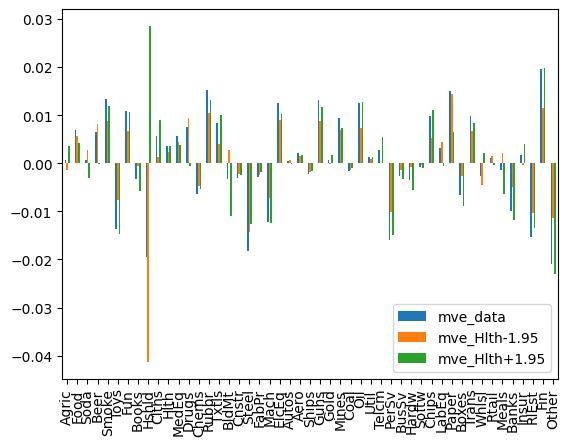

In [107]:
# your code below

# Make copies of `ERe` dataframe and name them `ERe_lower` and 'ERe_upper'
ERe_lower = ERe.copy()
ERe_upper = ERe.copy()

# Replace Hshld's mean with lower and upper CI bounds
ERe_lower['Hshld'] = ERe_ci.loc['Hshld', 'lower']
ERe_upper['Hshld'] = ERe_ci.loc['Hshld', 'upper']

# print(ERe_upper)

# Compute weights as in the above exercise and save the values of each in `Weights` dataframe



# lower
# Your CovRe
CovRe = ERe.cov()
invCovRe = np.linalg.inv(CovRe)

# Plug in appropriate variables in `invCovRe` and 'ERe'
raw_weights = invCovRe @ ERe_lower.mean()

# Normalize weights to the vol is 10%
x = 0.10 / np.sqrt(raw_weights @ invCovRe @ raw_weights * 12)
norm_weights = x * raw_weights

# Store in DataFrame
Weights['mve_Hlth-1.95'] = norm_weights




# upper
# Plug in appropriate variables in `invCovRe` and 'ERe'
raw_weights = invCovRe @ ERe_upper.mean()

# Normalize weights to the vol is 10%
x = 0.10 / np.sqrt(raw_weights @ invCovRe @ raw_weights * 12)
norm_weights = x * raw_weights

# Store in DataFrame
Weights['mve_Hlth+1.95'] = norm_weights




print(Weights)


# Bar plot
Weights.plot.bar()

your discussion below

1. How much do the weights change?
The weights change for a moderate amount. The lower weights seem to be closer to 0, while the upper weights seem to be farther.

2. Which assets are impacted? Why?
The asset impacted the most is Hlth because it was the one that we changed to either end of the CI. The other assets are impacted a little to compensate.

**8. Performance impact of estimation uncertainty**


Your `Weight` dataframe has 3 different weight schemes (three columns).

Do the followings:

1. compute the in-sample Sharpe Ratio for these 3 different weight schemes.

2. discuss the results that you obtained

**_Hint:_**
You should use the **real** data (e.g. `df`,`ERe`,`CovRe` ) to compute the Sharpe ratio (not the perturbed means in exercise 7).

In [108]:
# your code below

sharpe_normal = ERe.mean() @ Weights['mve_data'] / (Weights['mve_data'] @ CovRe @ Weights['mve_data'])**0.5
sharpe_lower = ERe.mean() @ Weights['mve_Hlth-1.95'] / (Weights['mve_Hlth-1.95'] @ CovRe @ Weights['mve_Hlth-1.95'])**0.5
sharpe_upper = ERe.mean() @ Weights['mve_Hlth+1.95'] / (Weights['mve_Hlth+1.95'] @ CovRe @ Weights['mve_Hlth+1.95'])**0.5

print(sharpe_normal)
print(sharpe_lower)
print(sharpe_upper)

0.3642851000207516
0.3335453459002056
0.3213808529614195


Seems like the sharpe ratio for the unperterbed weight schemes is better.

**9. Reproduce analysis of Exercises 7-8 for all assets**

Do the followings:

1. use a for loop to loop through the 49 portfolios and create the "perturbed" weights and the Sharpe Ratio of the perturbed weights by performing the same exercises as in exercise 7 and 8.

2. record for each asset the average drop in the Sharpe Ratio associated with the perturbation in the tangency portfolio weights.

3. store the results in a dataframe named `dSR` (difference in SR):
$$dSR[asset]=\frac{1}{2}\frac{SR(asset+1.95)-SR+SR(asset-1.95)-SR}{SR(data)}$$
where SR(asset+1.95) and SR(asset-1.95) were the Sharpe ratios obtained when you perturb the expected excess return of that asset to the upper and lower bound of the CI.
`dSR` should be a dataframe with industry names as index and a column, called `SR_change`, containing the results of the calculation from the expression above.

4. do a bar plot of this Sharpe ratio change.

Discuss the bar plot:

1. What do you think is the key takeaway from the analysis above

***Hint:***
Note that all you need to do here is to get the code you developed above and adapt it to work with a for loop.

***Hint:***
When saving into `dSR`, You can use .from_dict method of pd.DataFrame


<Axes: >

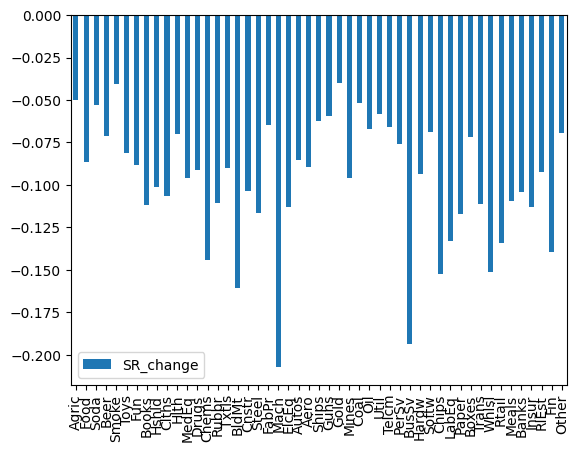

In [109]:
# your code below

# It's useful to use dictionary for this exercise
sr_changes = {}

# For each asset, do the same exercise
for asset in ERe.columns:
    # Write a code calculating Sharpe ratios using above exercise
    ERe_lower = ERe.copy()
    ERe_upper = ERe.copy()
    ERe_lower[asset] = ERe_ci.loc[asset, 'lower']
    ERe_upper[asset] = ERe_ci.loc[asset, 'upper']
    CovRe = ERe.cov()
    invCovRe = np.linalg.inv(CovRe)
    # lower
    lower_raw_weights = invCovRe @ ERe_lower.mean()
    # Normalize weights to the vol is 10%
    x = 0.10 / np.sqrt(lower_raw_weights @ invCovRe @ lower_raw_weights * 12)
    lower_norm_weights = x * lower_raw_weights
    # upper
    upper_raw_weights = invCovRe @ ERe_upper.mean()
    # Normalize weights to the vol is 10%
    x = 0.10 / np.sqrt(upper_raw_weights @ invCovRe @ upper_raw_weights * 12)
    upper_norm_weights = x * upper_raw_weights

    # Calculate SR
    sharpe_lower = ERe.mean() @ lower_norm_weights / (lower_norm_weights @ CovRe @ lower_norm_weights)**0.5
    sharpe_upper = ERe.mean() @ upper_norm_weights / (upper_norm_weights @ CovRe @ upper_norm_weights)**0.5

    # Compute average SR drop. Hint: Use the formula in the problem.
    sr_diff = 1/2 * (sharpe_upper + sharpe_lower - sharpe_normal * 2) / sharpe_normal
    sr_changes[asset] = sr_diff

# Save it into DataFrame
dSR = pd.DataFrame.from_dict(sr_changes, orient='index', columns=['SR_change'])

# Bar plot
dSR.plot.bar()


your discussion below

---
All of the SR changes are negative, so we should just use the sample mean estimator that is the best for our Covariance matrix (real data).



**10. Monte Carlo, part 1**

So far our focus is on the estimation uncertainty of risk premiums. Covariance matrices also need to be estimated.

You will now implement a Monte-Carlo method to evaluate the overall uncertainty in the construction of the tangency portfolio.

You already have the sample estimates from the vector of expected excess returns `ERe` and the variance-covariance matrix `CovRe`  (you used those in Exercise 6).

Now you use the function `np.random.multivariate_normal` to simulate draws from a multivariate normal distribution with vector of mean equal to `ERe` and the covariance matrix equal to `CovRe`.

Do the following:

1. write the code that draws ONE realization of returns for this set of 49 assets.

***Hint:***

you should get a vector 49 by 1 that changes every time you run the cell.

type `np.random.multivariate_normal?` to see how this function works



In [110]:
# your code below

np.random.multivariate_normal(ERe.mean(), CovRe)

array([  7.57946786,  -1.92211737, -13.40642156,  -7.74366242,
        -1.4473665 ,  -1.78687388,  -4.26364295,  -5.4861512 ,
        -3.68373945,  -0.21267687,  -0.67839773,   6.32196091,
         2.25999336,   1.94533131,  -1.45195727, -10.27981502,
        -6.8498255 ,  -0.12861402,   4.62859022,   1.39803251,
        -0.62994397,   2.22820199,  -0.06668238,  -0.54225724,
         0.30363819,   7.61532365,   4.05898298,   3.31540786,
        -0.30938598,  -2.3287611 ,   0.76010096,   1.00843531,
         1.03223951,   0.76203454,   2.5178576 ,   3.80867159,
         6.19682037,   4.50242577,  -2.13137253,  -3.2848462 ,
         4.46795899,   2.0642115 ,  -3.50809097,  -3.82994418,
        -4.04840508,  -1.70847013,  -3.70358886,   0.87015113,
         3.77796349])

**11. Monte Carlo, part 2**

Do the followings:

1. now set the parameter `size` in the `multivaraite_normal` function to draw T realizations of the 49 assets, where you set T to the number of months you have in the data set.

2. print the shape of your draw. This should return you a T by N matrix of returns, something with exactly the same shape as our data set.

***Hint:***
every time you run the cell again you get a different realization.



In [111]:
# your code below
draw = np.random.multivariate_normal(ERe.mean(), CovRe, size=ERe.shape[0])
print(draw.shape)
print(ERe.shape)
print(draw)

(553, 49)
(553, 49)
[[  4.23018865   5.23242205   7.74568218 ...  12.4296159   19.23712914
    7.84343735]
 [ -7.66739558   2.77687454  -5.09031007 ... -14.51331894  -5.83138462
   -6.45261991]
 [  0.49233535  -2.24914441  -1.48417182 ...  -9.74762303  -2.1255276
   -1.48595867]
 ...
 [ -4.50937834  -7.22221949   2.83007331 ...  -7.51998729  -3.80831711
   -1.26327153]
 [-14.38250338  -3.3857315   -0.93843575 ...  -5.6709199   -9.6468945
  -10.84783001]
 [ -8.57578536   1.76866536  10.61978383 ...   2.93238917   1.53800673
    1.58258209]]


**12. Monte Carlo, part 3**

Do the followings:

1. copy the code above, so you have a simulated sample of monthly industry returns.

2. use the simulated return data and the weights in `mve_data` column of the dataframe `Weights` to construct a time-series of portfolio excess return. That is use the weights you constructed using the sample moments of the original sample.

3. compute and print its Sharpe Ratio.

***Hint:***

Every time you run this cell you should get a different Sharpe Ratio. This variation reflects the amount of overall uncertainty built in our investment strategy.

In [112]:
# your code below
simulated_returns = np.random.multivariate_normal(ERe.mean(), CovRe, size=ERe.shape[0])
w_mve = Weights['mve_data'].values

# Compute time-series of simulated portfolio returns
simulated_port_returns = draw @ w_mve

# Compute Sharpe Ratio of the simulated portfolio
sim_sharpe = simulated_port_returns.mean() / simulated_port_returns.std()
print(sim_sharpe)

0.4156599943864766


**13. Monte Carlo, part 4**

Now copy the code of the question above and write a for loop around it.

Do the followings:

1. loop throught this code 1000 times and each time record the resulting Sharpe Ratio.

2. save this in a dataframe called `MC`.

3. create a histogram of these Sharpe Ratios with 50 bins using the method `.hist`

Discuss the plot:

1. what do you conclude?

array([[<Axes: title={'center': 'MC_sharpe'}>]], dtype=object)

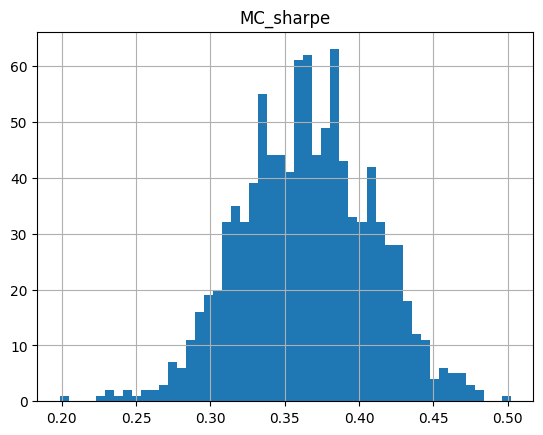

In [113]:
# your code below

# Prepare saving space
mc_sharpes = pd.DataFrame(columns=['MC_sharpe'])

# Run simulation 1000 times
for iter in range(1000):
    simulated_returns = np.random.multivariate_normal(ERe.mean(), CovRe, size=ERe.shape[0])
    w_mve = Weights['mve_data'].values

    # Compute time-series of simulated portfolio returns
    simulated_port_returns = simulated_returns @ w_mve

    # Compute Sharpe Ratio of the simulated portfolio
    mc_sharpe_value = simulated_port_returns.mean() / simulated_port_returns.std()
    mc_sharpes.loc[iter] = {'MC_sharpe': mc_sharpe_value}

# create a histogram of these Sharpe Ratios with 50 bins using the method .hist
mc_sharpes.hist(bins=50)

It seems like the distribution of Sharpe Ratios from the Monte Carlo simulation of our estimated MVE portfolio weights is approximately normal. The mean seems to be around 0.37.

**14. Please explain why an investor should care about these results.**

your answer below


They should care because as an investor, it is most optimal to hold the MVE portfolio. This MC simulation shows the potential Sharpe Ratios possible from holding this portfolio.